# Student Info
## Name: Jia Changyu
## English Name: Iris
## ID: C00292876

# 1. Introduction

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import time
import warnings
warnings.filterwarnings('ignore')

import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, roc_curve, auc
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Embedding, SimpleRNN, LSTM, Dense, Dropout, 
    SpatialDropout1D, Input, Concatenate, GlobalMaxPooling1D
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import plot_model

In [35]:
dataset_path = "../data/IMDB Dataset.csv"

imbd = pd.read_csv(dataset_path)


# 2. Initial Exploration

In [36]:
# 数据加载与探索
print(f"Shape of the dataset: {imbd.shape}")
print(f"Dataset Information:")
print(f"  Total number of comments: {len(imbd):,}")
print(f"  Column names: {imbd.columns.tolist()}")

Shape of the dataset: (50000, 2)
Dataset Information:
  Total number of comments: 50,000
  Column names: ['review', 'sentiment']


In [37]:
print("\nDistribution of Emotional Labels:")
sentiment_counts = imbd['sentiment'].value_counts()
for sentiment, count in sentiment_counts.items():
    percentage = count / len(imbd) * 100
    print(f"  {sentiment}: {count:,} ({percentage:.1f}%)")

# 检查缺失值
print("\nMissing value check:")
print(imbd.isnull().sum())


Distribution of Emotional Labels:
  positive: 25,000 (50.0%)
  negative: 25,000 (50.0%)

Missing value check:
review       0
sentiment    0
dtype: int64


In [38]:
# 将标签转换为数值
imbd['sentiment_numeric'] = imbd['sentiment'].map({'positive': 1, 'negative': 0})


Comment text statistics:
  Average word count: 231
  The longest comment (in terms of word count): 2470
  Shortest Comment (Word Count): 4


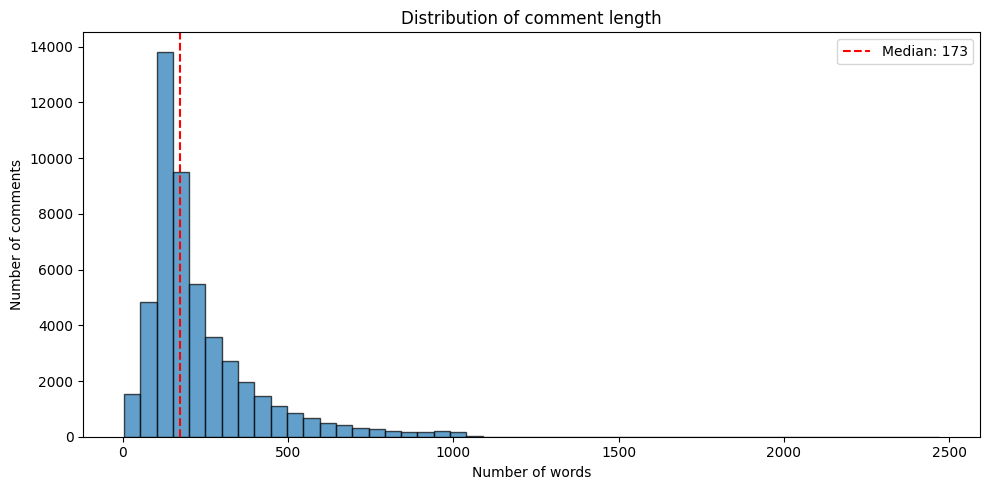

In [39]:
# 统计分析评论长度
imbd['word_count'] = imbd['review'].apply(lambda x: len(x.split()))
print("\nComment text statistics:")
print(f"  Average word count: {imbd['word_count'].mean():.0f}")
print(f"  The longest comment (in terms of word count): {imbd['word_count'].max()}")
print(f"  Shortest Comment (Word Count): {imbd['word_count'].min()}")

# 可视化评论长度分布
plt.figure(figsize=(10, 5))
plt.hist(imbd['word_count'], bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Number of words')
plt.ylabel('Number of comments')
plt.title('Distribution of comment length')
plt.axvline(imbd['word_count'].median(), color='red', linestyle='--', 
            label=f'Median: {imbd["word_count"].median():.0f}')
plt.legend()
plt.tight_layout()
plt.show()


In [40]:
# 数据准备
MAX_VOCAB_SIZE = 10000
MAX_SEQUENCE_LENGTH = 200
EMBEDDING_DIM = 12
TEST_SIZE = 0.2
VALIDATION_SPLIT = 0.2
BATCH_SIZE = 64
EPOCHS = 15

# 准备特征和标签
X = imbd['review'].values
y = imbd['sentiment_numeric'].values

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=42, stratify=y
)

print(f"Data split:")
print(f"  Training set: {len(X_train):,} comments ({len(X_train)/len(X)*100:.1f}%)")
print(f"  Test set: {len(X_test):,} comments ({len(X_test)/len(X)*100:.1f}%)")
print(f"  Training set positive ratio: {y_train.mean():.2%}")
print(f"  Test set positive ratio: {y_test.mean():.2%}")

# 创建并训练分词器
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token='<OOV>', filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n')
tokenizer.fit_on_texts(X_train)

# 获取词汇表信息
word_index = tokenizer.word_index
vocab_size = min(len(word_index), MAX_VOCAB_SIZE - 1) + 1
print(f"\nTokenizer vocabulary:")
print(f"  Total vocabulary size: {len(word_index):,}")
print(f"  Used vocabulary size: {vocab_size:,}")
print(f"  Coverage: {vocab_size/len(word_index)*100:.1f}%")

# 转换为序列
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# 分析序列长度
seq_lengths = [len(seq) for seq in X_train_seq]
print(f"\nTraining set sequence length statistics:")
print(f"  Average length: {np.mean(seq_lengths):.1f}")
print(f"  Median length: {np.median(seq_lengths):.0f}")
print(f"  90% percentile: {np.percentile(seq_lengths, 90):.0f}")

# 填充序列
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')

print(f"\nPadded sequence shapes:")
print(f"  Training set: {X_train_pad.shape}")
print(f"  Test set: {X_test_pad.shape}")


Data split:
  Training set: 40,000 comments (80.0%)
  Test set: 10,000 comments (20.0%)
  Training set positive ratio: 50.00%
  Test set positive ratio: 50.00%

Tokenizer vocabulary:
  Total vocabulary size: 111,959
  Used vocabulary size: 10,000
  Coverage: 8.9%

Training set sequence length statistics:
  Average length: 235.2
  Median length: 176
  90% percentile: 460

Padded sequence shapes:
  Training set: (40000, 200)
  Test set: (10000, 200)


In [41]:
# SimpleRNN 模型
print("\nBuilding a SimpleRNN model")
model = Sequential(name="SimpleRNN")
model.add(Embedding(vocab_size, EMBEDDING_DIM, input_length=MAX_SEQUENCE_LENGTH,
                    embeddings_regularizer=l2(1e-6)))
model.add(SpatialDropout1D(0.2))
model.add(SimpleRNN(64, return_sequences=True, dropout=0.3, recurrent_dropout=0.2,
                    kernel_regularizer=l2(1e-6), recurrent_regularizer=l2(1e-6)))
model.add(SimpleRNN(32, return_sequences=False, dropout=0.3, recurrent_dropout=0.2,
                    kernel_regularizer=l2(1e-6), recurrent_regularizer=l2(1e-6)))
model.add(Dense(16, activation='relu', kernel_regularizer=l2(1e-6)))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))

model.summary()


Building a SimpleRNN model


Model: "SimpleRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_3             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_6 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_7 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [42]:
# 编译与训练
print("\nCompiling and training the model")
model.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall(), tf.keras.metrics.AUC()]
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7),
    ModelCheckpoint('best_simplernn.keras', monitor='val_accuracy', save_best_only=True)
]

start_time = time.time()
history = model.fit(
    X_train_pad, y_train,
    batch_size=64,
    epochs=15,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)
train_time = time.time() - start_time
print(f"\nTraining time: {train_time:.2f} seconds")


Compiling and training the model
Epoch 1/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 29s 51ms/step - accuracy: 0.5031 - auc_1: 0.5038 - loss: 0.7081 - precision_1: 0.5029 - recall_1: 0.5010 - val_accuracy: 0.4996 - val_auc_1: 0.5001 - val_loss: 0.6940 - val_precision_1: 0.5009 - val_recall_1: 0.4028 - learning_rate: 0.0010
Epoch 2/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 24s 49ms/step - accuracy: 0.4972 - auc_1: 0.4946 - loss: 0.6960 - precision_1: 0.4956 - recall_1: 0.3447 - val_accuracy: 0.4989 - val_auc_1: 0.4995 - val_loss: 0.6936 - val_precision_1: 0.0000e+00 - val_recall_1: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 25s 50ms/step - accuracy: 0.4964 - auc_1: 0.4972 - loss: 0.6944 - precision_1: 0.4929 - recall_1: 0.2732 - val_accuracy: 0.5034 - val_auc_1: 0.4999 - val_loss: 0.6935 - val_precision_1: 0.5076 - val_recall_1: 0.2993 - learning_rate: 0.0010
Epoch 4/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 25s 51ms/step - accuracy: 0.4971 - auc_1: 0.4982 - loss: 0.6939 - precision_1:

In [43]:
# 评估模型
print("\nEvaluating the model on the test set")
model.load_weights('best_simplernn.keras')
test_results = model.evaluate(X_test_pad, y_test, verbose=0, return_dict=True)
print("\nTest set metrics:")
for metric, value in test_results.items():
    print(f"  {metric}: {value:.4f}")

y_pred_proba = model.predict(X_test_pad, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()
acc = accuracy_score(y_test, y_pred)
print(f"\nTest set accuracy: {acc:.4f}")

print("\nTest set classification report:")
print(classification_report(y_test, y_pred, target_names=['negative', 'positive']))


Evaluating the model on the test set

Test set metrics:
  accuracy: 0.5092
  auc_1: 0.5001
  loss: 0.6934
  precision_1: 0.5154
  recall_1: 0.3070

Test set accuracy: 0.5091

Test set classification report:
              precision    recall  f1-score   support

    negative       0.51      0.71      0.59      5000
    positive       0.52      0.31      0.38      5000

    accuracy                           0.51     10000
   macro avg       0.51      0.51      0.49     10000
weighted avg       0.51      0.51      0.49     10000




Visualizing training curves and confusion matrix


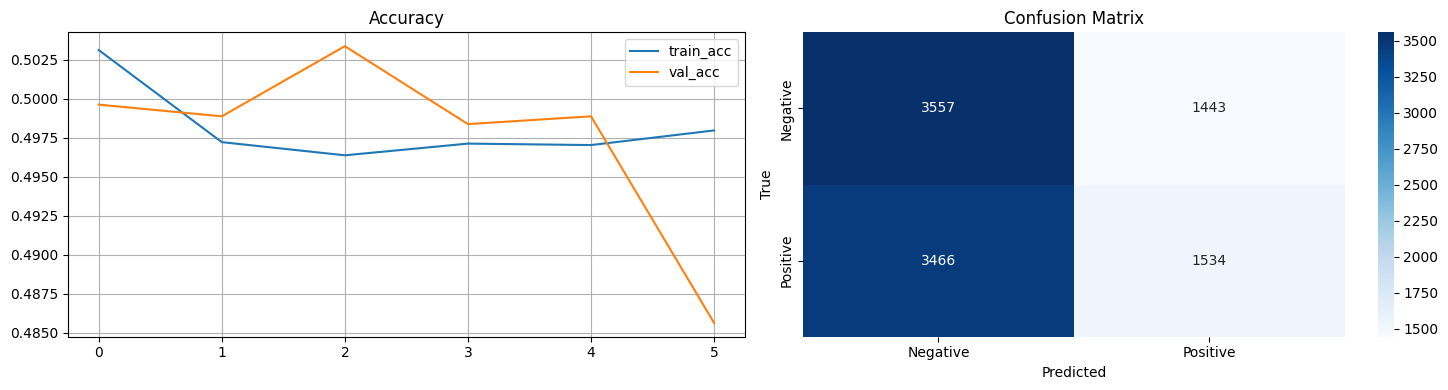

In [44]:
# 可视化
print("\nVisualizing training curves and confusion matrix")
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# 准确率曲线
axes[0].plot(history.history['accuracy'], label='train_acc')
axes[0].plot(history.history['val_accuracy'], label='val_acc')
axes[0].set_title('Accuracy')
axes[0].legend()
axes[0].grid(True)

# 混淆矩阵
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
axes[1].set_title('Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.show()

In [45]:
# 预测示例
print("\nPrediction Example")
def predict(text):
    text = re.sub(r'<.*?>', '', str(text))
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = ' '.join(text.lower().split())
    seq = tokenizer.texts_to_sequences([text])
    pad = pad_sequences(seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')
    prob = model.predict(pad, verbose=0)[0][0]
    sentiment = "positive" if prob > 0.5 else "negative"
    print(f"Review: {text[:80]}...")
    print(f"Prediction: {sentiment} (Probability={prob:.4f})\n")

test_reviews = [
    "This movie was absolutely fantastic! The acting was superb and the story kept me engaged throughout.",
    "Terrible film. Complete waste of time. Poor acting, boring plot.",
    "An absolute masterpiece! Highly recommended!"
]
for rev in test_reviews:
    predict(rev)


[9] Prediction Example
Review: this movie was absolutely fantastic the acting was superb and the story kept me ...
Prediction: positive (Probability=0.5003)

Review: terrible film complete waste of time poor acting boring plot...
Prediction: negative (Probability=0.4982)

Review: an absolute masterpiece highly recommended...
Prediction: negative (Probability=0.4989)

